## Setup

In [19]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/analysis`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/analysis/Project.toml`
  [13f3f980] CairoMakie v0.15.11
⌅ [780c37f4] Carlo v0.2.5
  [074ae576] CarloAnalysis v1.0.0-DEV `../CarloAnalysis.jl`
  [a93c6f00] DataFrames v1.8.2
  [7a1cc6ca] FFTW v1.10.0
  [f67ccb44] HDF5 v0.17.3
  [033835bb] JLD2 v0.6.4
  [90137ffa] StaticArrays v1.9.18
Info Packages marked with ⌅ have new versions available but compatibility constraints restrict them from upgrading. To see why use `status --outdated`


In [20]:
using CairoMakie
using Carlo.ResultTools
using CarloAnalysis
using DataFrames
using FFTW
using HDF5
using JLD2
using LinearAlgebra
using StaticArrays

In [21]:
function generate_spins(jobname, task_no)
    fig = Figure(size=(400, 400))

    task_str = lpad(task_no, 4, "0")
    h5open("../eta-jobs/$jobname.data/task$task_str/run0001.dump.h5") do file
        spins = map(
            t -> [t[:data][1], t[:data][2], t[:data][3]],
            read(file, "simulation/etas")
        )
        spin_xs = map(v -> v[1], spins)
        spin_ys = map(v -> v[2], spins)
        spin_zs = map(v -> v[3], spins)
        Lx, Ly = size(spins)
        fig[1,1] = Axis(fig; title="Spins", backgroundcolor="black")
        strength = vec(spin_zs)
        arrows2d!(1:Lx, 1:Ly, spin_xs, spin_ys, lengthscale=0.5, align=:center, color=strength)
    end

    return fig
end

generate_spins (generic function with 1 method)

In [30]:
function generate_spinks(jobname, task_no; run_no=1, dimer=1)
    fig = Figure(size=(800, 400))

    task_str = lpad(task_no, 4, "0")
    run_str = lpad(run_no, 4, "0")
    h5open("../dimer-jobs/$jobname.data/task$task_str/run$run_str.dump.h5") do file
        spins = read(file["simulation/etaks"])
        spin_mags = sum(abs2.(spins), dims=3)[:,:,1]
        fig[1,1] = ax = Axis(fig; title="ηk correlations")
        heatmap!(ax, spin_mags, colorrange=(0,1))

        spins = read(file, "simulation/spinks")
        spin_mags = abs2.(spins)[:,:,dimer]
        fig[1,2] = ax = Axis(fig; title = "sk correlations")
        heatmap!(ax, spin_mags)
    end

    return fig
end

generate_spinks (generic function with 2 methods)

## VBS Init

In [47]:
results = JobResult("../dimer-jobs", "vbs")

JobResult("../dimer-jobs", "vbs", 10×63 DataFrame
 Row │ ηk_Γ                               ηk_corr_part_K2                    η ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  - ⋯
   2 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   3 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[9.…
   4 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   5 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…    ⋯
   6 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   7 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   8 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   9 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…    ⋯
  

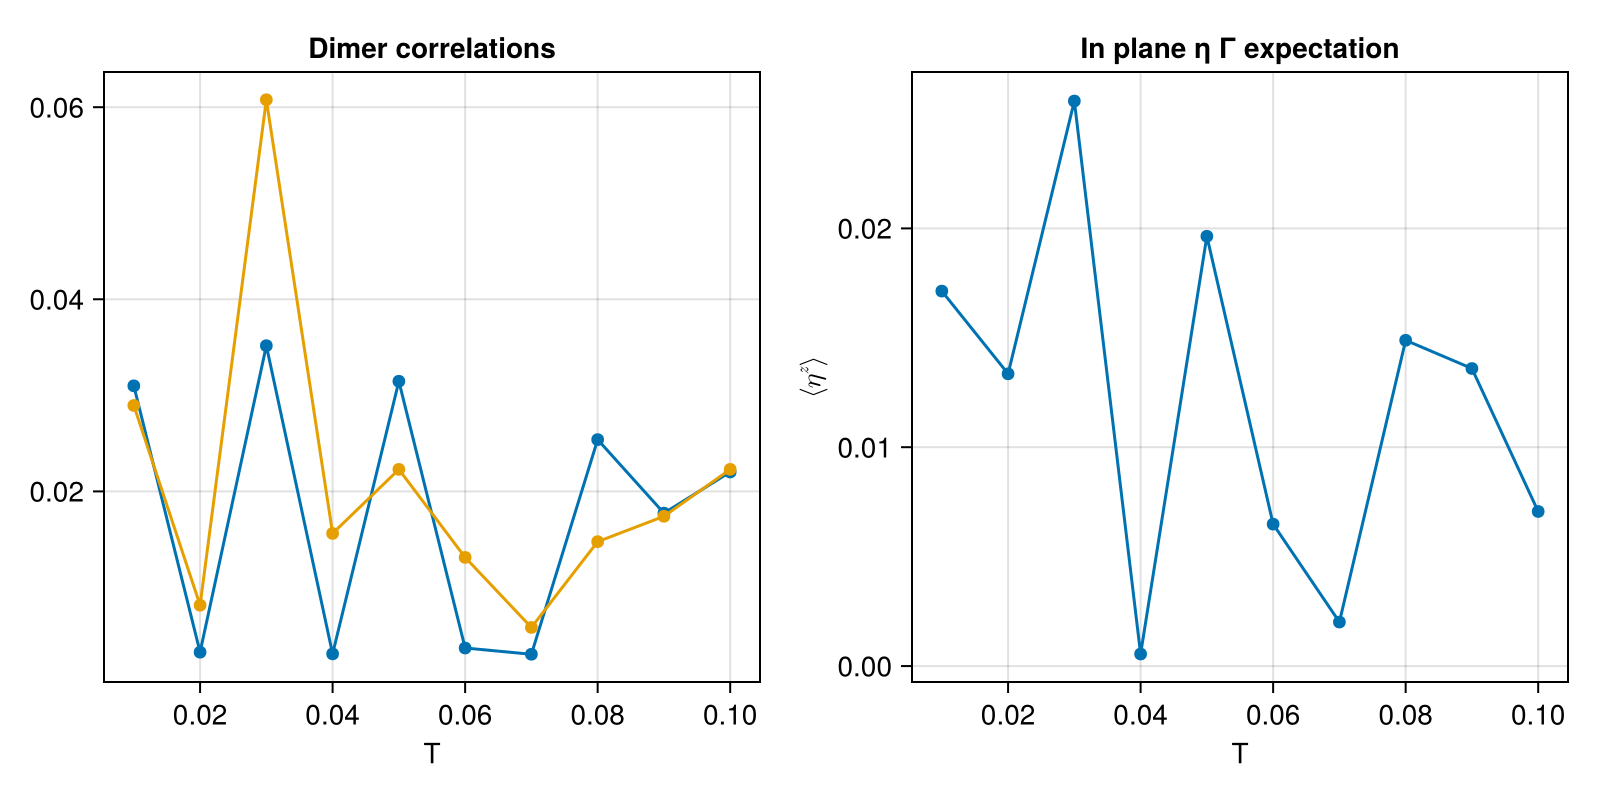

In [48]:
fig = Figure(size=(800, 400))
fig[1,1] = ax = Axis(fig, title="Dimer correlations", xlabel="T")
generate_plot!(ax, :T, :sk_corr_part_K, results.data) do sk
    sk[3]
end
generate_plot!(ax, :T, :sk_corr_M2, results.data) do sk
    sk[3]
end
fig[1,2] = ax = Axis(fig, title="In plane η Γ expectation", xlabel="T", ylabel=L"\langle\eta^z\rangle")
generate_plot!(ax, :T, :ηk_corr_Γ, results.data) do ηk
    real(ηk[1,1] + ηk[2,2])
end
fig

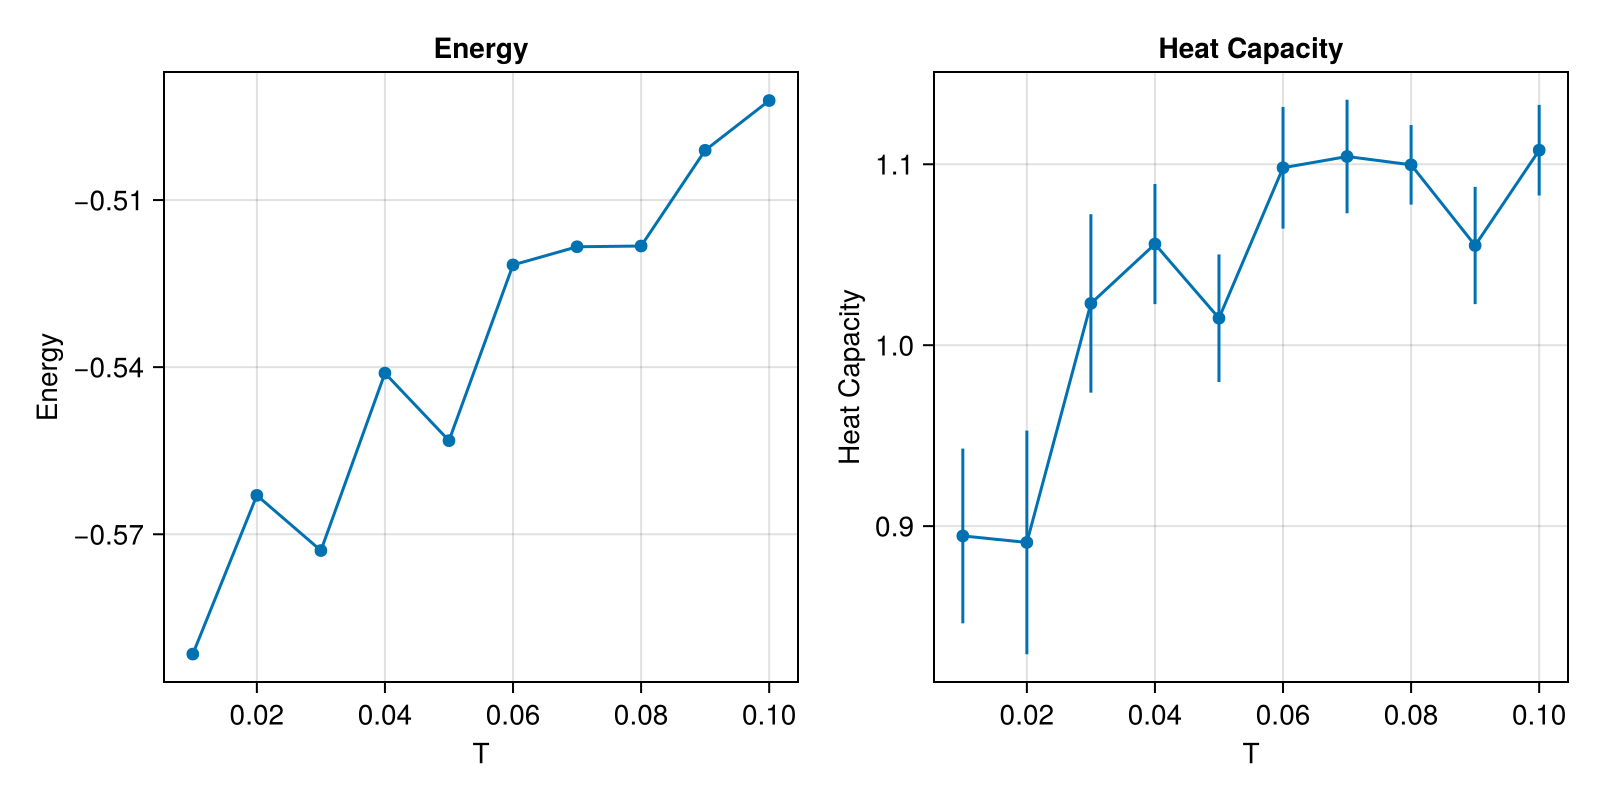

In [49]:
fig = Figure(size=(800, 400))
fig[1,1] = ax = Axis(fig, title="Energy", xlabel="T", ylabel="Energy")
generate_plot!(ax, :T, :Energy, results.data)
fig[1,2] = ax = Axis(fig, title="Heat Capacity", xlabel="T", ylabel="Heat Capacity")
generate_plot!(ax, :T, :HeatCap, results.data)
fig

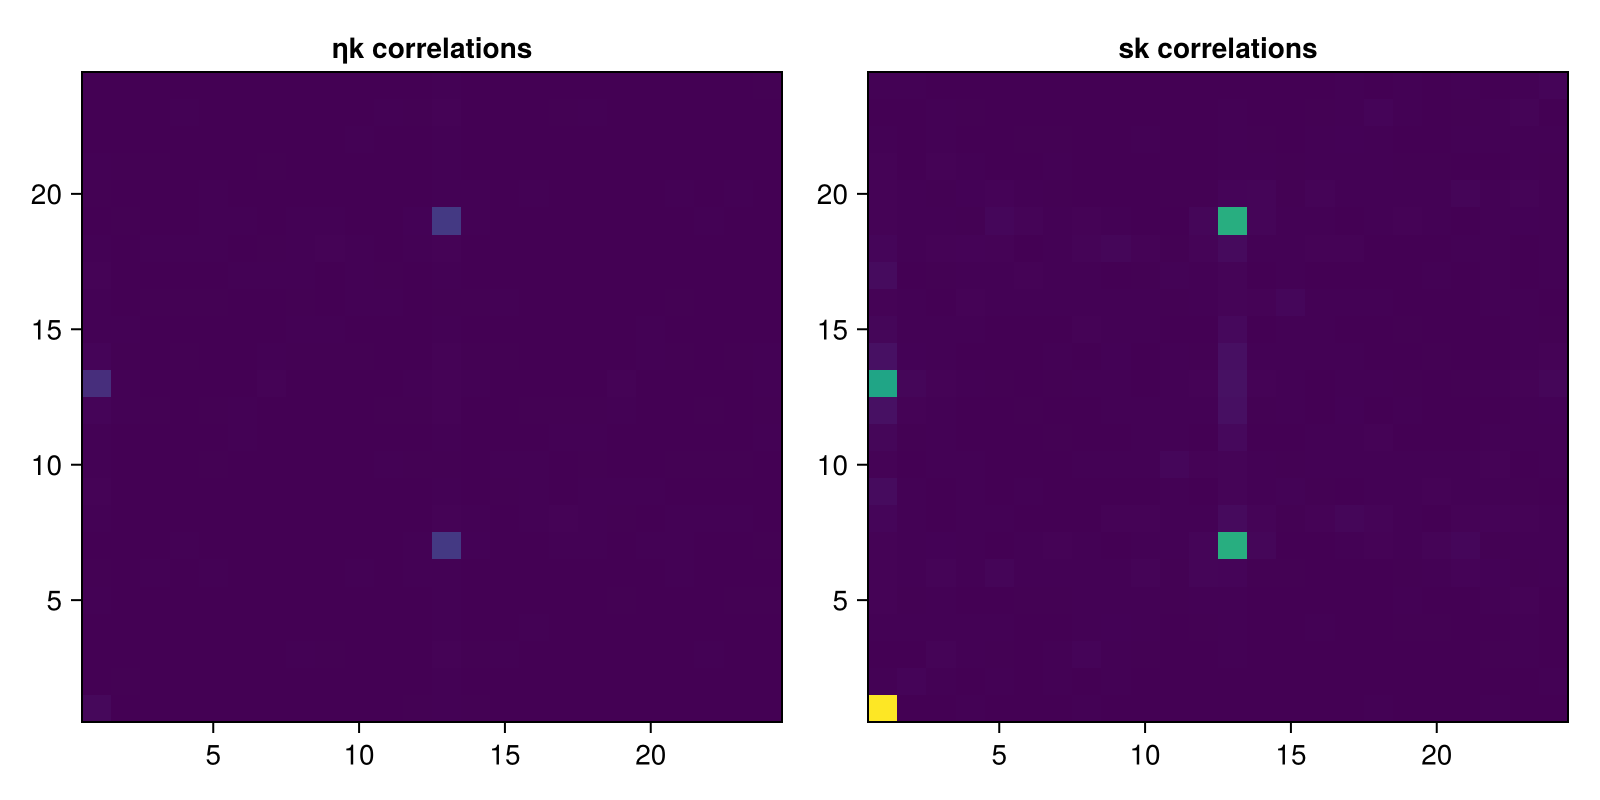

In [50]:
generate_spinks("vbs", 1, dimer=3)

In [51]:
mctimes = get_mctime_data(results, :ηxy, :ηk_corr_M2, :sk_corr_part_K, :sk_corr_M2)
nothing

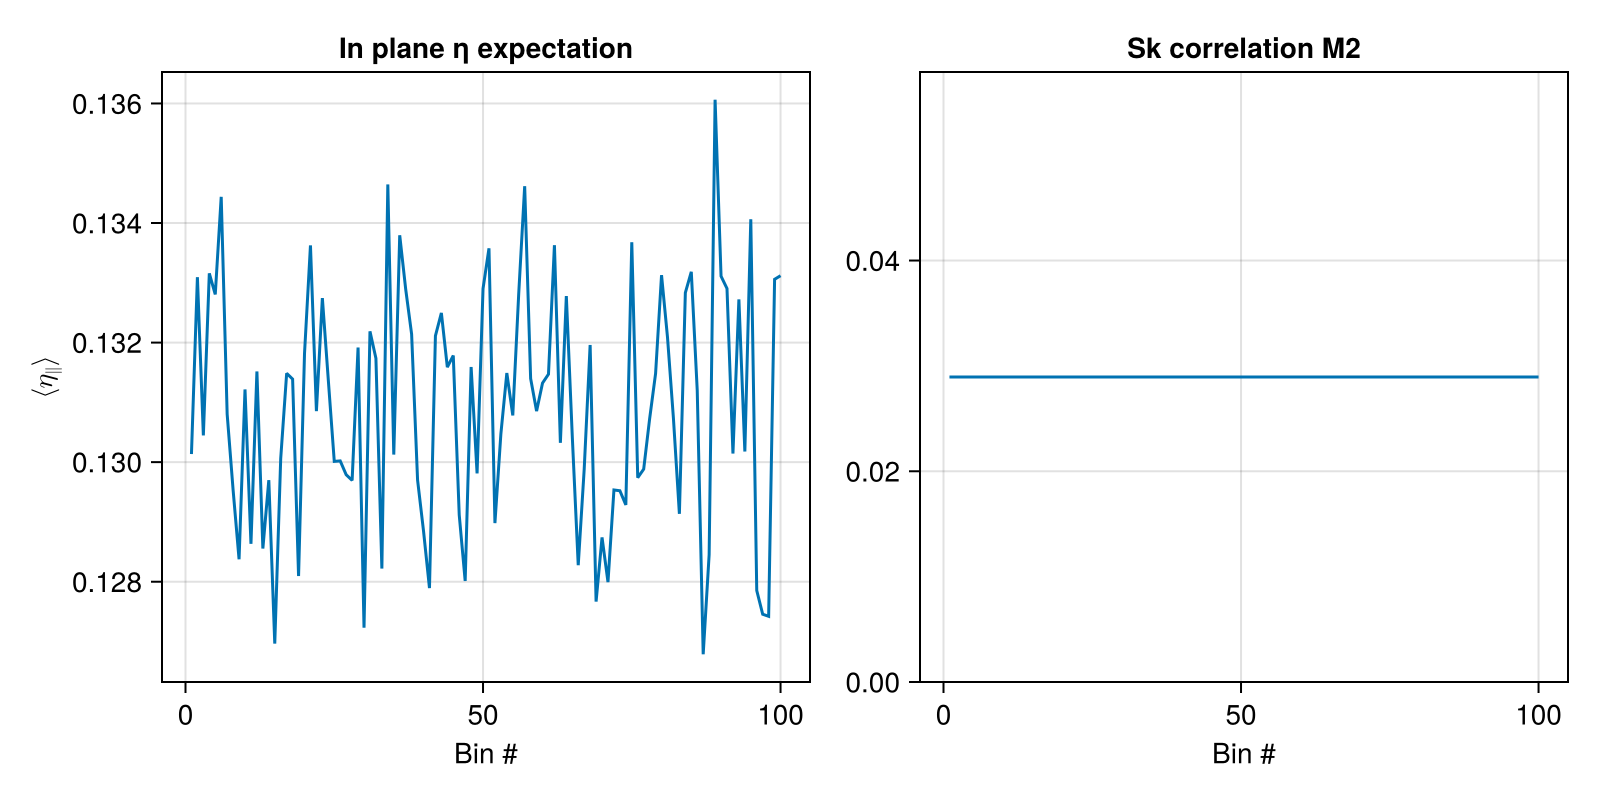

In [52]:
i = 1
fig = Figure(size=(800, 400))
data = mctimes[i]
fig[1,1] = ax = Axis(fig, title="In plane η expectation", xlabel="Bin #", ylabel=L"\langle\eta_\parallel\rangle")
lines!(ax, data[:, :ηxy])
fig[1,2] = ax = Axis(fig, title="Sk correlation M2", xlabel="Bin #")
lines!(ax, getindex.(data[:, :sk_corr_M2], 3))
fig

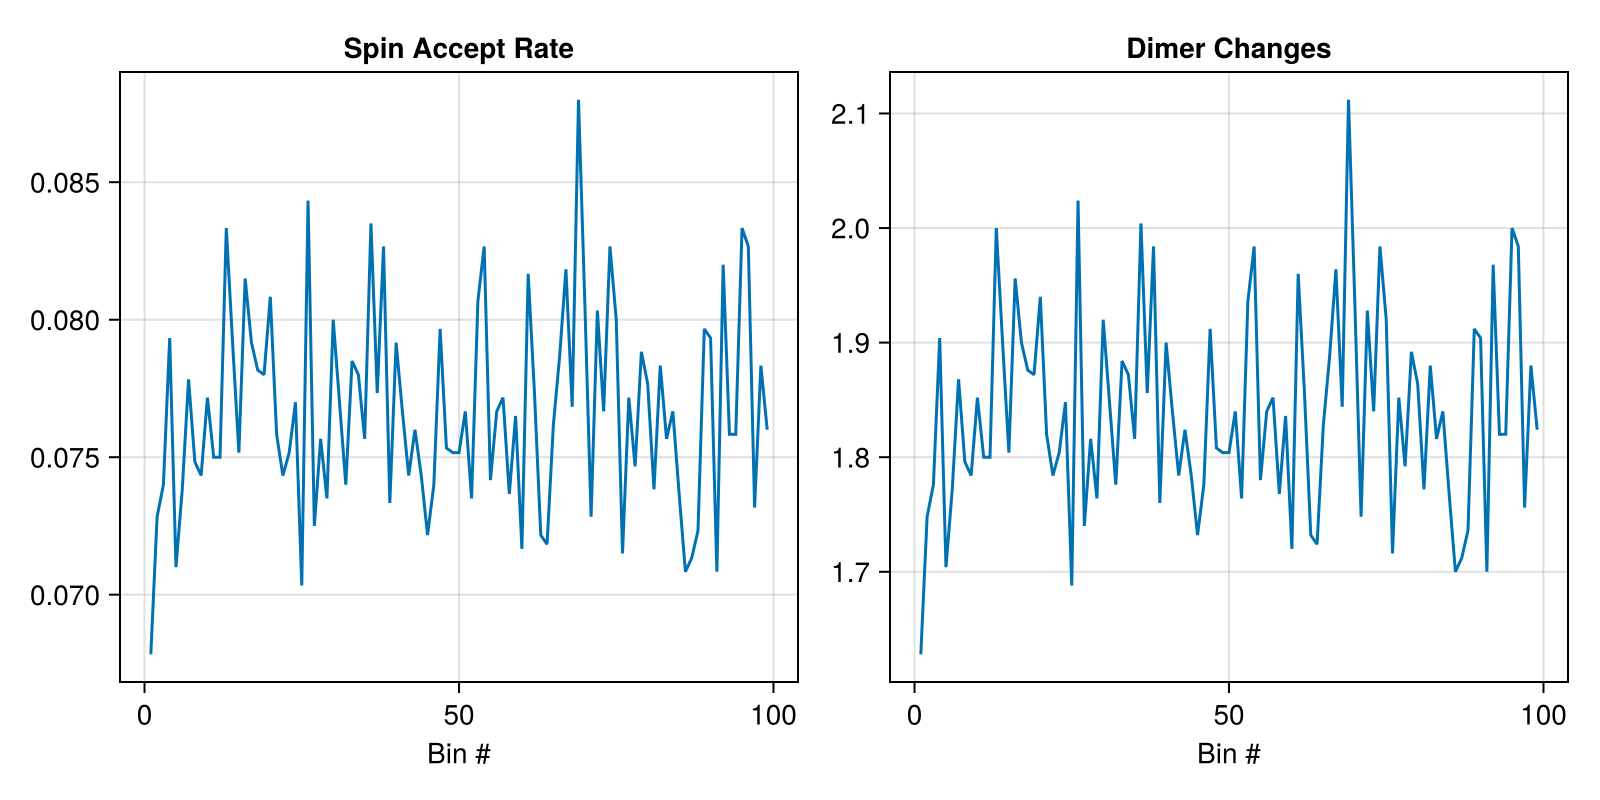

In [55]:
i = 1
fig = Figure(size=(800, 400))
data = get_mctime_data(results, :AcceptRateS, :DimerChanges)[i]
fig[1,1] = ax = Axis(fig, title="Spin Accept Rate", xlabel="Bin #")
lines!(ax, data[:, :AcceptRateS])
fig[1,2] = ax = Axis(fig, title="Dimer Changes", xlabel="Bin #")
lines!(ax, data[:, :DimerChanges])
fig